# Adaptive Dropout PINN

This notebook is a guided version of the adaptive dropout PINN script. Each code section is preceded by two short sentences explaining what that part contributes to the algorithm.

Import of required packages


In [1]:
using NeuralPDE, Lux, Plots
using DomainSets
using Random
using StatsBase
using Statistics
using Zygote
using Optimisers

using NeuralPDE: recursive_eltype, EltypeAdaptor, safe_get_device

rng = MersenneTwister(1234)

MersenneTwister(1234)

Problem definition. I set intervals and Spike_beta parameters as consts so it will be easier to change the problem(Poisson eq) for tests. Basically, Spike_beta sets the sharpness of the spike shape of the function

In [2]:
@parameters x y
@variables u(..)
Dxx = Differential(x)^2
Dyy = Differential(y)^2

const SPIKE_BETA = 4
const XMIN = -2.0
const XMAX = 2.0
const YMIN = -2.0
const YMAX = 2.0
const DROPOUT_RATE = 0.05

eq = Dxx(u(x, y)) + Dyy(u(x, y)) ~
     4 * SPIKE_BETA * (SPIKE_BETA * (x^2 + y^2) - 1) * exp(-SPIKE_BETA * (x^2 + y^2))

bcs = [u(x, YMIN) ~ exp(-SPIKE_BETA * (x^2 + YMIN^2)),
       u(x, YMAX) ~ exp(-SPIKE_BETA * (x^2 + YMAX^2)),
       u(XMIN, y) ~ exp(-SPIKE_BETA * (XMIN^2 + y^2)),
       u(XMAX, y) ~ exp(-SPIKE_BETA * (XMAX^2 + y^2))]

domains = [x ∈ Interval(XMIN, XMAX), y ∈ Interval(YMIN, YMAX)]

2-element Vector{Symbolics.VarDomainPairing}:
 Symbolics.VarDomainPairing(x, -2.0 .. 2.0)
 Symbolics.VarDomainPairing(y, -2.0 .. 2.0)

This cell builds the neural network with a variational dropout layer inside the hidden representation. NeuralPDE then constructs the symbolic and numerical problem objects whose residual functions are reused later. Since the boundaries are defined as 4 sets of points and collocation points is the other set, default dropout was sampling new mask after each error evaluation on each subset(It samples it each time it is called, idk). To avoid this issue, I used VariationalHiddenDropout which resamples new mask only if asked to, so now it works good.

In [3]:
chain = Chain(
    Dense(2, 50, tanh),
    Dense(50, 50, tanh),
    VariationalHiddenDropout(DROPOUT_RATE; dims=1),
    Dense(50, 1)
)

init_states = Lux.testmode(Lux.initialstates(MersenneTwister(4321), chain))
phi = NeuralPDE.Phi(Lux.StatefulLuxLayer{false}(chain, nothing, init_states))
discretization = PhysicsInformedNN(chain, StochasticTraining(1500, 300);
    init_states=init_states,
    phi=phi)
@named pde_system = PDESystem(eq, bcs, domains, [x, y], [u(x, y)])

prob = discretize(pde_system, discretization)
symprob = symbolic_discretize(pde_system, discretization)

analytic_sol_func(x, y) = exp(-SPIKE_BETA * (x^2 + y^2))
u_scalar(z, theta) = first(phi(z, theta))

u_scalar (generic function with 1 method)

These helper functions switch the Lux model between dropout training mode and deterministic test mode. Training and acquisition refresh dropout masks, while monitoring and plotting turn dropout off for reproducible evaluation.

In [4]:
function set_dropout_training!(training::Bool)
    phi.smodel.st_any = training ? Lux.trainmode(phi.smodel.st_any) : Lux.testmode(phi.smodel.st_any)
    return nothing
end

function refresh_dropout_masks!()
    phi.smodel.st_any = Lux.update_state(phi.smodel.st_any, :update_mask, Val(true))
    return nothing
end

function begin_dropout_training_pass!()
    set_dropout_training!(true)
    refresh_dropout_masks!()
    return nothing
end

function with_dropout_mode(f, training::Bool)
    old_state = phi.smodel.st_any
    phi.smodel.st_any = training ? Lux.trainmode(old_state) : Lux.testmode(old_state)

    try
        return f()
    finally
        phi.smodel.st_any = old_state
    end
end

with_dropout_mode (generic function with 1 method)

This cell creates interior and boundary collocation point sets used in the PINN loss. The conversion helper makes sure these explicit point matrices match NeuralPDE's expected parameter eltype and device.

In [5]:
const ELT = recursive_eltype(symprob.flat_init_params)
to_train_set(X) = X |> safe_get_device(symprob.flat_init_params) |> EltypeAdaptor{ELT}()

function sample_interior_points(rng, n)
    X = zeros(Float64, 2, n)
    X[1, :] .= rand(rng, n) .* (XMAX - XMIN) .+ XMIN
    X[2, :] .= rand(rng, n) .* (YMAX - YMIN) .+ YMIN
    return to_train_set(X)
end

function boundary_sets(n)
    xs = collect(range(XMIN, XMAX; length=n))
    ys = collect(range(YMIN, YMAX; length=n))

    Xbottom = hcat([[x, YMIN] for x in xs]...)
    Xtop = hcat([[x, YMAX] for x in xs]...)
    Xleft = hcat([[XMIN, y] for y in ys]...)
    Xright = hcat([[XMAX, y] for y in ys]...)

    return [to_train_set(Xbottom),
            to_train_set(Xtop),
            to_train_set(Xleft),
            to_train_set(Xright)]
end

boundary_sets (generic function with 1 method)

This cell defines the PDE residual loss, boundary loss, deterministic monitoring loss, and benchmark L2 error. The L2 error uses the analytic solution only to evaluate this test problem, not to train the network.

In [6]:
pde_residual_fun = symprob.loss_functions.datafree_pde_loss_functions[1]
bc_residual_funs = symprob.loss_functions.datafree_bc_loss_functions

function total_loss(theta, Xint, Xbc_sets; lambda_bc=10.0, weight_decay=0.0)
    r_pde = vec(pde_residual_fun(Xint, theta))
    l_pde = mean(abs2, r_pde)

    bc_terms = map(zip(bc_residual_funs, Xbc_sets)) do (bc_fun, Xbc)
        mean(abs2, vec(bc_fun(Xbc, theta)))
    end
    l_bc = mean(bc_terms)

    return l_pde + lambda_bc * l_bc + weight_decay * sum(abs2, theta)
end

function deterministic_loss(theta, Xint, Xbc_sets; lambda_bc=10.0, weight_decay=0.0)
    return with_dropout_mode(false) do
        total_loss(theta, Xint, Xbc_sets;
            lambda_bc=lambda_bc,
            weight_decay=weight_decay)
    end
end

function l2_error(theta; n_eval=81)
    return with_dropout_mode(false) do
        xs = range(XMIN, XMAX; length=n_eval)
        ys = range(YMIN, YMAX; length=n_eval)

        u_pred = [u_scalar([x, y], theta) for x in xs for y in ys]
        u_exact = [analytic_sol_func(x, y) for x in xs for y in ys]

        sqrt(mean((u_pred .- u_exact).^2))
    end
end

l2_error (generic function with 1 method)

This cell computes the adaptive acquisition function from MC-dropout residual statistics. Candidate points are preferred when their mean PDE residual is large and/or their residual varies strongly across dropout masks.

In [7]:
function dropout_residual_statistics(Xpool, theta; n_mc=20)
    n = size(Xpool, 2)
    mean_residual = zeros(Float64, n)
    m2_residual = zeros(Float64, n)

    for i in 1:n_mc
        begin_dropout_training_pass!()
        residual = vec(pde_residual_fun(Xpool, theta))
        delta = residual .- mean_residual
        mean_residual .+= delta ./ i
        m2_residual .+= delta .* (residual .- mean_residual)
    end

    set_dropout_training!(false)
    residual_variance = n_mc > 1 ? m2_residual ./ (n_mc - 1) : m2_residual
    return mean_residual, residual_variance
end

function acquisition_distribution(Xpool, theta; eps=1e-8, alpha=2.0, n_mc=20, beta_uncertainty=1.0)
    mean_residual, residual_variance = dropout_residual_statistics(Xpool, theta; n_mc=n_mc)
    acquisition = mean_residual .^ 2 .+ beta_uncertainty .* residual_variance .+ eps
    weights = acquisition .^ alpha
    probabilities = weights ./ sum(weights)
    return acquisition, probabilities
end

function add_adaptive_points(rng, Xint, Xpool, theta;
    n_add,
    eps,
    alpha,
    n_mc,
    beta_uncertainty
)
    acquisition, probabilities = acquisition_distribution(Xpool, theta;
        eps=eps,
        alpha=alpha,
        n_mc=n_mc,
        beta_uncertainty=beta_uncertainty)

    n_select = min(n_add, size(Xpool, 2))
    idx = sample(rng, 1:size(Xpool, 2), ProbabilityWeights(probabilities), n_select; replace=false)
    Xnew = Xpool[:, idx]
    keep_idx = setdiff(1:size(Xpool, 2), idx)
    Xpool_remaining = Xpool[:, keep_idx]

    return hcat(Xint, Xnew), Xpool_remaining, Xnew, acquisition, probabilities
end

add_adaptive_points (generic function with 1 method)

These functions record deterministic diagnostics and train one block of Adam steps with dropout active. The monitoring loss is deterministic because dropout is disabled during evaluation, making the history comparable across iterations.

In [8]:
function record_training_state!(
    theta,
    Xint,
    Xbc_sets;
    iter,
    lambda_bc,
    weight_decay,
    iter_hist,
    loss_hist,
    l2_hist,
    best_l2_ref,
    best_theta_ref
)
    current_loss = deterministic_loss(theta, Xint, Xbc_sets;
        lambda_bc=lambda_bc,
        weight_decay=weight_decay)
    current_l2 = l2_error(theta)

    push!(iter_hist, iter)
    push!(loss_hist, current_loss)
    push!(l2_hist, current_l2)

    if current_l2 < best_l2_ref[]
        best_l2_ref[] = current_l2
        best_theta_ref[] = deepcopy(theta)
    end

    return nothing
end

function train_dropout_block!(
    theta,
    opt_state,
    Xint,
    Xbc_sets;
    iters,
    record_every,
    lambda_bc,
    weight_decay,
    iter_hist,
    loss_hist,
    l2_hist,
    total_iters_ref,
    best_l2_ref,
    best_theta_ref
)
    loss_closure = theta_arg -> total_loss(theta_arg, Xint, Xbc_sets;
        lambda_bc=lambda_bc,
        weight_decay=weight_decay)

    for _ in 1:iters
        begin_dropout_training_pass!()
        grads = Zygote.gradient(loss_closure, theta)[1]
        opt_state, theta = Optimisers.update(opt_state, theta, grads)
        total_iters_ref[] += 1

        if total_iters_ref[] % record_every == 0
            record_training_state!(theta, Xint, Xbc_sets;
                iter=total_iters_ref[],
                lambda_bc=lambda_bc,
                weight_decay=weight_decay,
                iter_hist=iter_hist,
                loss_hist=loss_hist,
                l2_hist=l2_hist,
                best_l2_ref=best_l2_ref,
                best_theta_ref=best_theta_ref)
        end
    end

    if isempty(iter_hist) || iter_hist[end] != total_iters_ref[]
        record_training_state!(theta, Xint, Xbc_sets;
            iter=total_iters_ref[],
            lambda_bc=lambda_bc,
            weight_decay=weight_decay,
            iter_hist=iter_hist,
            loss_hist=loss_hist,
            l2_hist=l2_hist,
            best_l2_ref=best_l2_ref,
            best_theta_ref=best_theta_ref)
    end

    set_dropout_training!(false)
    return theta, opt_state
end

train_dropout_block! (generic function with 1 method)

This function runs the full adaptive dropout algorithm. It alternates between dropout training, MC-dropout acquisition over the candidate pool, adding new collocation points, and retraining on the expanded set.

In [9]:
function adaptive_dropout_train!(theta0;
    rng,
    n_init,
    n_bc,
    initial_iters,
    rounds,
    iters_per_round,
    record_every,
    pool_size,
    n_add,
    lr,
    lambda_bc,
    weight_decay,
    eps,
    alpha,
    n_mc_acquisition,
    beta_uncertainty
)
    Xint = sample_interior_points(rng, n_init)
    Xbc_sets = boundary_sets(n_bc)
    Xpool = sample_interior_points(rng, pool_size)

    theta = deepcopy(theta0)
    opt_rule = Optimisers.Adam(lr)
    opt_state = Optimisers.setup(opt_rule, theta)

    iter_hist = Int[]
    loss_hist = Float64[]
    l2_hist = Float64[]
    added_hist = Matrix{Float64}[]
    pool_hist = Matrix{Float64}[]
    acquisition_hist = Vector{Float64}[]
    probability_hist = Vector{Float64}[]
    total_iters_ref = Ref(0)
    best_l2_ref = Ref(Inf)
    best_theta_ref = Ref(deepcopy(theta))

    println("=== Initial dropout training ===")
    theta, opt_state = train_dropout_block!(
        theta,
        opt_state,
        Xint,
        Xbc_sets;
        iters=initial_iters,
        record_every=record_every,
        lambda_bc=lambda_bc,
        weight_decay=weight_decay,
        iter_hist=iter_hist,
        loss_hist=loss_hist,
        l2_hist=l2_hist,
        total_iters_ref=total_iters_ref,
        best_l2_ref=best_l2_ref,
        best_theta_ref=best_theta_ref)

    for round in 1:rounds
        println("=== Adaptive dropout round $round ===")

        if size(Xpool, 2) == 0
            println("candidate pool is empty; stopping adaptive refinement.")
            break
        end

        Xpool_before = Xpool
        Xint, Xpool, Xnew, acquisition, probabilities = add_adaptive_points(
            rng,
            Xint,
            Xpool,
            theta;
            n_add=n_add,
            eps=eps,
            alpha=alpha,
            n_mc=n_mc_acquisition,
            beta_uncertainty=beta_uncertainty)

        push!(added_hist, Array(Xnew))
        push!(pool_hist, Array(Xpool_before))
        push!(acquisition_hist, collect(acquisition))
        push!(probability_hist, collect(probabilities))

        opt_state = Optimisers.setup(opt_rule, theta)
        theta, opt_state = train_dropout_block!(
            theta,
            opt_state,
            Xint,
            Xbc_sets;
            iters=iters_per_round,
            record_every=record_every,
            lambda_bc=lambda_bc,
            weight_decay=weight_decay,
            iter_hist=iter_hist,
            loss_hist=loss_hist,
            l2_hist=l2_hist,
            total_iters_ref=total_iters_ref,
            best_l2_ref=best_l2_ref,
            best_theta_ref=best_theta_ref)

        println("deterministic loss = ", loss_hist[end])
        println("deterministic L2 error = ", l2_hist[end])
        println("interior points = ", size(Xint, 2))
        println("candidate pool points = ", size(Xpool, 2))
    end

    return theta,
           best_theta_ref[],
           best_l2_ref[],
           Xint,
           Xbc_sets,
           iter_hist,
           loss_hist,
           l2_hist,
           added_hist,
           pool_hist,
           acquisition_hist,
           probability_hist
end

adaptive_dropout_train! (generic function with 1 method)

This helper evaluates the final network on a plotting grid with dropout turned off. Because this benchmark problem has an exact solution, it also returns the absolute pointwise error.

In [10]:
function evaluate_on_grid(theta; dx=0.05)
    return with_dropout_mode(false) do
        xs = XMIN:dx:XMAX
        ys = YMIN:dx:YMAX

        u_pred = reshape([u_scalar([x, y], theta) for x in xs for y in ys],
            (length(xs), length(ys)))
        u_exact = reshape([analytic_sol_func(x, y) for x in xs for y in ys],
            (length(xs), length(ys)))

        xs, ys, u_pred, u_exact, abs.(u_pred .- u_exact)
    end
end

evaluate_on_grid (generic function with 1 method)

This cell launches the adaptive dropout training run and stores all histories needed for diagnostics. The final contour plots later use the last trained model, while the best model is still tracked for comparison.

In [11]:
train_start_time = time()
println("Sharp Gaussian Poisson problem with SPIKE_BETA = ", SPIKE_BETA)
println("Adaptive PINN training with dropout rate = ", DROPOUT_RATE)

(
theta_dropout,
theta_best_dropout,
best_l2_dropout,
Xint,
Xbc_sets,
iter_hist,
loss_hist,
l2_hist,
added_hist,
pool_hist,
acquisition_hist,
probability_hist
) =
    adaptive_dropout_train!(prob.u0;
        rng=rng,
        n_init=600,
        n_bc=80,
        initial_iters=500,
        rounds=3,
        iters_per_round=500,
        record_every=50,
        pool_size=900,
        n_add=50,
        lr=0.0002,
        lambda_bc=10.0,
        weight_decay=1e-6,
        eps=1e-8,
        alpha=2.0,
        n_mc_acquisition=30,
        beta_uncertainty=1.0
    )

total_iteration_time = time() - train_start_time

println("Dropout loss history = ", loss_hist)
println("Dropout L2 history = ", l2_hist)
println("Total iteration time (s) = ", total_iteration_time)
println("Last recorded deterministic loss = ", loss_hist[end])
println("Last recorded deterministic L2 error = ", l2_hist[end])
println("Best deterministic L2 error during training = ", best_l2_dropout)

Sharp Gaussian Poisson problem with SPIKE_BETA = 4
Adaptive PINN training with dropout rate = 0.05
=== Initial dropout training ===
=== Adaptive dropout round 1 ===


┌ Warning: `training` is set to `Val{true}()` but is not being used within an autodiff call (gradient, jacobian, etc...). This will be slow. If you are using a `Lux.jl` model, set it to inference (test) mode using `LuxCore.testmode`. Reliance on this behavior is discouraged, and is not guaranteed by Semantic Versioning, and might be removed without a deprecation cycle. It is recommended to fix this issue in your code.
└ @ LuxLib.Utils C:\Users\turar\.julia\packages\LuxLib\pDhNx\src\utils.jl:346


deterministic loss = 0.1632631394926514
deterministic L2 error = 0.09003624290833703
interior points = 650
candidate pool points = 850
=== Adaptive dropout round 2 ===
deterministic loss = 0.08227263071840155
deterministic L2 error = 0.04754946658303164
interior points = 700
candidate pool points = 800
=== Adaptive dropout round 3 ===
deterministic loss = 0.06543559453008163
deterministic L2 error = 0.04349446447498393
interior points = 750
candidate pool points = 750
Dropout loss history = [10.261721238895813, 4.984768145118118, 2.937238653148282, 1.9213582687825015, 1.3428914049196707, 0.9717980738463095, 0.7249362255447108, 0.5675629363295209, 0.46953271901600085, 0.3875140729073737, 0.40997588286565684, 0.3098755891364861, 0.2524723882998479, 0.23399755367898845, 0.19371191577252916, 0.19774999150879483, 0.16831063395945942, 0.14563437887944355, 0.1726330089155489, 0.1632631394926514, 0.16717432208240057, 0.14514210348132311, 0.14060441316913702, 0.1193017785098848, 0.1566042270073

This cell plots the exact solution, the last-iteration PINN prediction, and the absolute error. The exact solution and error plot are for validation only and would be omitted for an unknown-solution PDE.

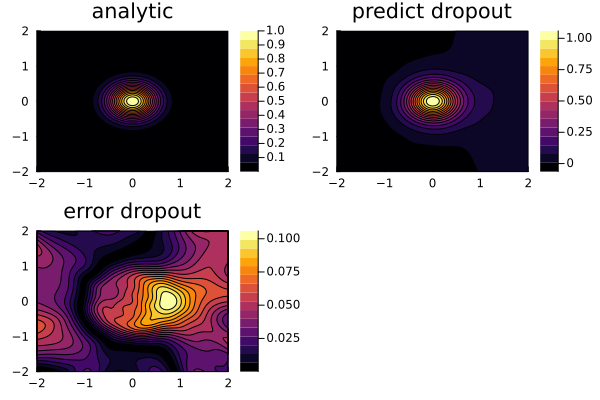

Final last-model deterministic training loss = 0.06543559453008163
Best-model deterministic training loss = 0.0646845050654266
Final last-model grid L2 error = 0.04349446447498393
Best-model L2 error recorded during training = 0.034213427298049354


In [12]:
xs, ys, u_predict_dropout, u_real, diff_u_dropout = evaluate_on_grid(theta_dropout)

p1 = plot(xs, ys, u_real, linetype=:contourf, title="analytic")
p2 = plot(xs, ys, u_predict_dropout, linetype=:contourf, title="predict dropout")
p3 = plot(xs, ys, diff_u_dropout, linetype=:contourf, title="error dropout")
display(plot(p1, p2, p3))

last_grid_l2_error = sqrt(mean((u_predict_dropout .- u_real).^2))
final_training_loss = deterministic_loss(theta_dropout, Xint, Xbc_sets;
    lambda_bc=10.0,
    weight_decay=1e-6)
best_training_loss = deterministic_loss(theta_best_dropout, Xint, Xbc_sets;
    lambda_bc=10.0,
    weight_decay=1e-6)

println("Final last-model deterministic training loss = ", final_training_loss)
println("Best-model deterministic training loss = ", best_training_loss)
println("Final last-model grid L2 error = ", last_grid_l2_error)
println("Best-model L2 error recorded during training = ", best_l2_dropout)

This cell plots the deterministic training loss and benchmark L2 error over training. The loss is the weighted PDE and boundary objective, while the L2 error compares the predicted solution to the known exact solution.

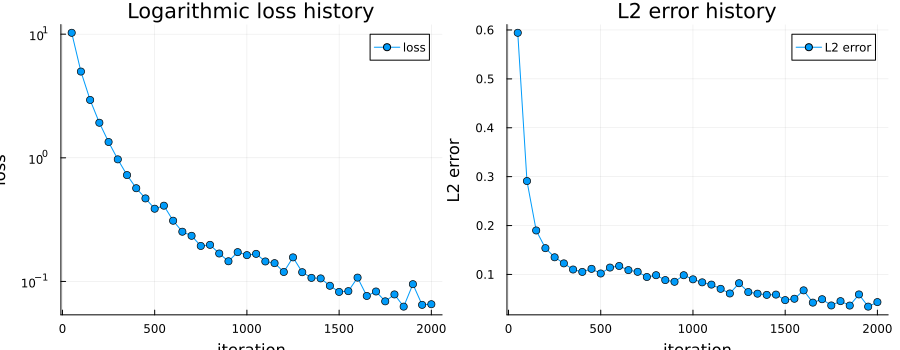

Last acquisition min probability = 2.5144336723151354e-6
Last acquisition mean probability = 0.0012500000000000002
Last acquisition max probability = 0.05691948144995074


In [13]:
if !isempty(probability_hist)
    last_probabilities = probability_hist[end]
    println("Last acquisition min probability = ", minimum(last_probabilities))
    println("Last acquisition mean probability = ", mean(last_probabilities))
    println("Last acquisition max probability = ", maximum(last_probabilities))
end

p_loss = plot(iter_hist, loss_hist,
    marker=:circle,
    yscale=:log10,
    xlabel="iteration",
    ylabel="loss",
    title="Logarithmic loss history",
    label="loss")

p_l2 = plot(iter_hist, l2_hist,
    marker=:circle,
    xlabel="iteration",
    ylabel="L2 error",
    title="L2 error history",
    label="L2 error")

display(plot(p_loss, p_l2, layout=(1, 2), size=(900, 350)))

This final cell visualizes where the adaptive algorithm added new interior collocation points. It also shows the last acquisition distribution over the candidate pool and highlights which points were selected.

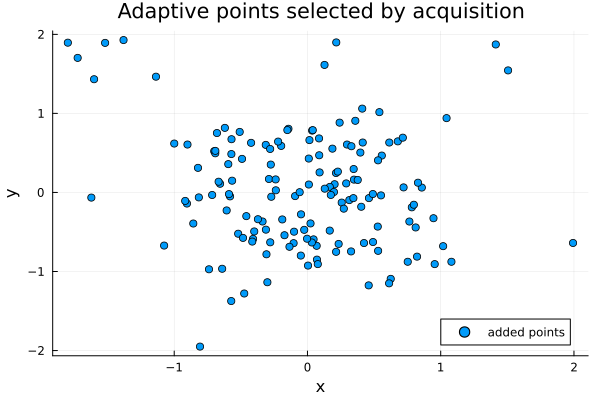

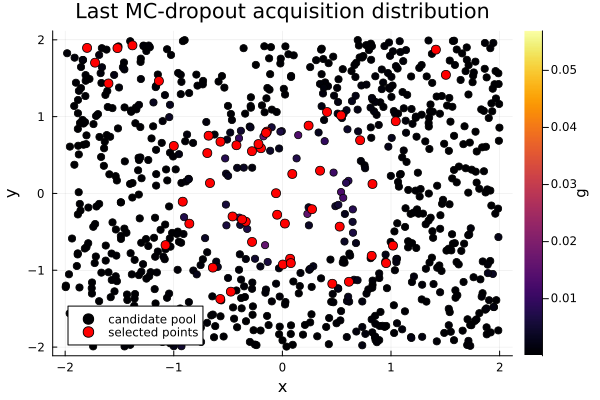

In [14]:
if !isempty(added_hist)
    Xnew_all = reduce(hcat, added_hist)

    p_added = scatter(Xnew_all[1, :], Xnew_all[2, :],
        ms=4,
        xlabel="x",
        ylabel="y",
        label="added points",
        title="Adaptive points selected by acquisition")
    display(p_added)

    Xpool_last = pool_hist[end]
    probabilities_last = probability_hist[end]
    Xnew_last = added_hist[end]

    p_acq = scatter(Xpool_last[1, :], Xpool_last[2, :],
        marker_z=probabilities_last,
        ms=4,
        xlabel="x",
        ylabel="y",
        label="candidate pool",
        colorbar_title="g",
        title="Last MC-dropout acquisition distribution")
    scatter!(p_acq, Xnew_last[1, :], Xnew_last[2, :],
        ms=5,
        markercolor=:red,
        label="selected points")
    display(p_acq)
end